In [1]:
#Load and inspect data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')
df.shape        # check size
df.head()       # look at columns
df.info()       # check data types
df.isnull().sum() # check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Fraud vs Non-Fraud Distribution')

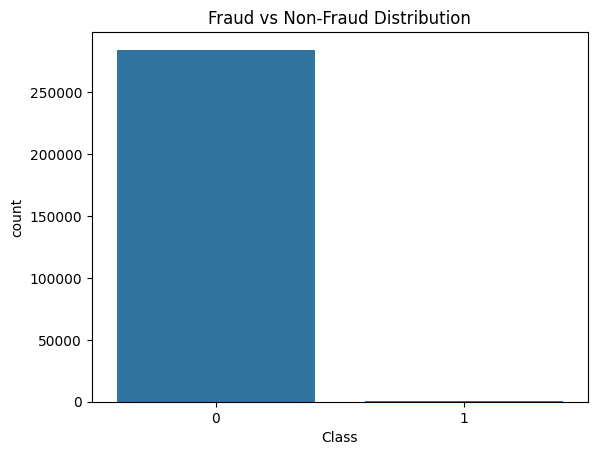

In [3]:
#class imbalance
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('Fraud vs Non-Fraud Distribution')

Text(0.5, 1.0, 'Fraud Transaction Amounts')

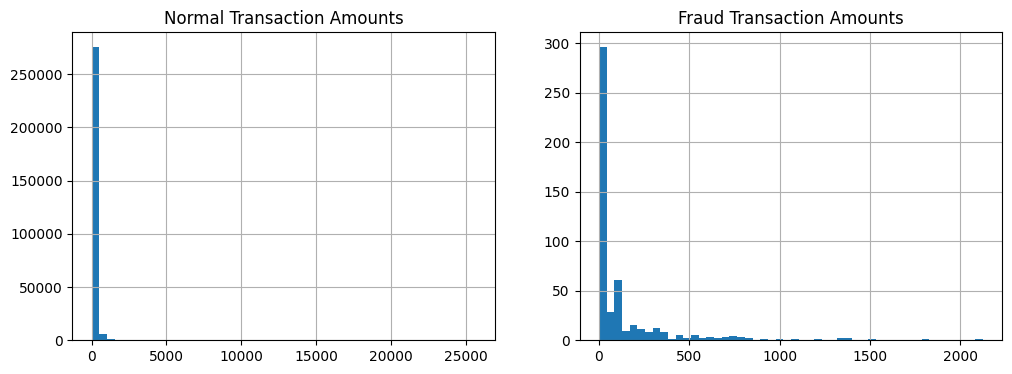

In [4]:
#Transaction amount analysis
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df[df['Class']==0]['Amount'].hist(ax=axes[0], bins=50)
axes[0].set_title('Normal Transaction Amounts')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50)
axes[1].set_title('Fraud Transaction Amounts')

Text(0.5, 1.0, 'Feature Correlation Matrix')

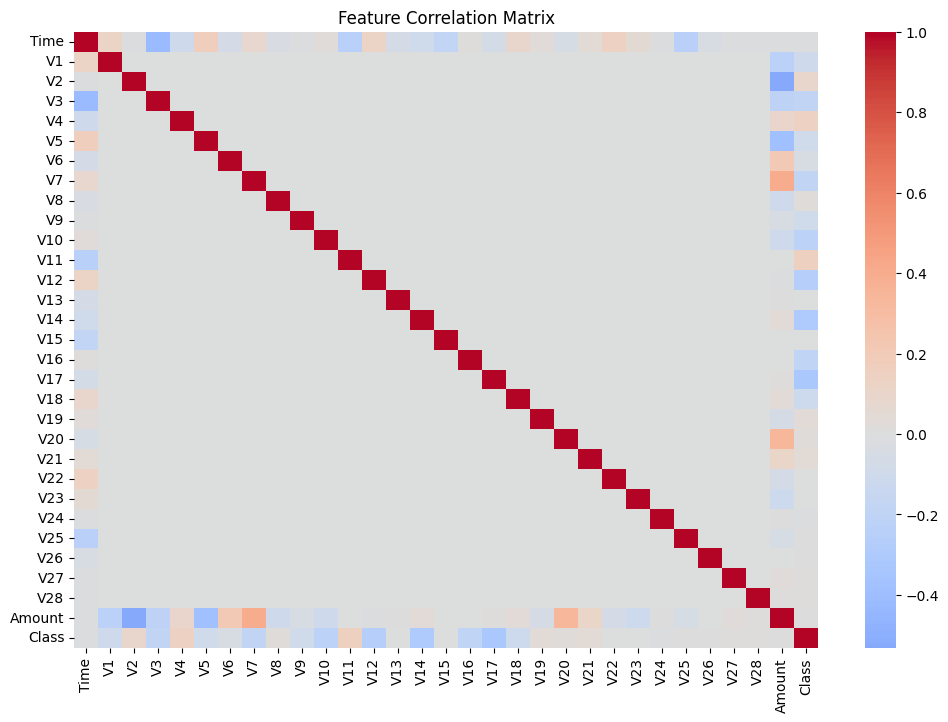

In [6]:
#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

In [10]:
#Preprocessing 
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Scale Amount and Time (other features are already scaled)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [13]:
# Model Training & Comparison 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss'
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Report': classification_report(y_test, y_pred)
    }
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
AUC-ROC: 0.9698
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Model: Random Forest
AUC-ROC: 0.9802
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962


Model: XGBoost
AUC-ROC: 0.9687
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.17      0.89      0.29        98

    accuracy                           0.99     56962
   macro avg  

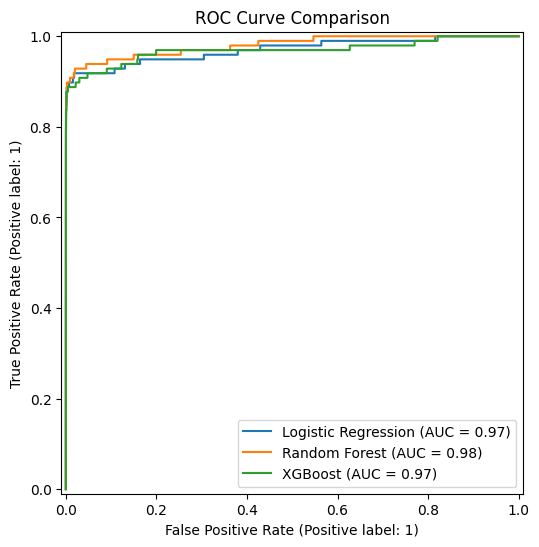

In [14]:
#ROC curves
fig, ax = plt.subplots(figsize=(8,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
plt.title('ROC Curve Comparison')
plt.savefig('../roc_curve.png')

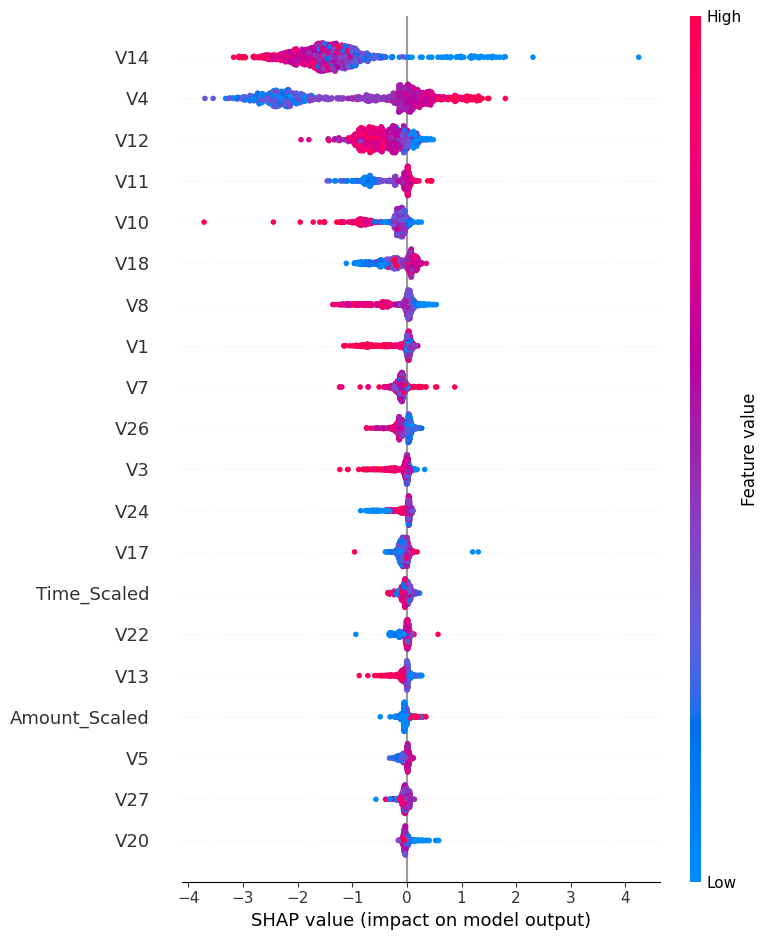

In [16]:
#SHAP Explainability
import shap

# Use XGBoost as your final model (it'll perform best)
best_model = models['XGBoost']


explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test[:1000])  # use sample for speed

# Summary plot — shows top features driving fraud prediction
shap.summary_plot(shap_values, X_test[:1000], show=False)
plt.savefig('../shap_summary.png', bbox_inches='tight')
plt.show()

# Force plot for a single prediction — shows why ONE transaction was flagged
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [17]:
import joblib

joblib.dump(best_model, '../models/xgb_fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Model saved successfully")

Model saved successfully
